In [6]:
# Import modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [7]:
sonar = pd.read_csv("../data/sonar.csv", header=None)

# Print basic info of the data sonar
print("Dimensions ")
print(f"Lignes : {sonar.shape[0]}")
print(f"Colonnes de caractéristiques : {sonar.shape[1] - 1}")

print("\n Head of the data")
print(sonar.head())

Dimensions 
Lignes : 208
Colonnes de caractéristiques : 60

 Head of the data
       0       1       2       3       4       5       6       7       8   \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

       9   ...      51      52      53      54      55      56      57  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
4  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   

       58     

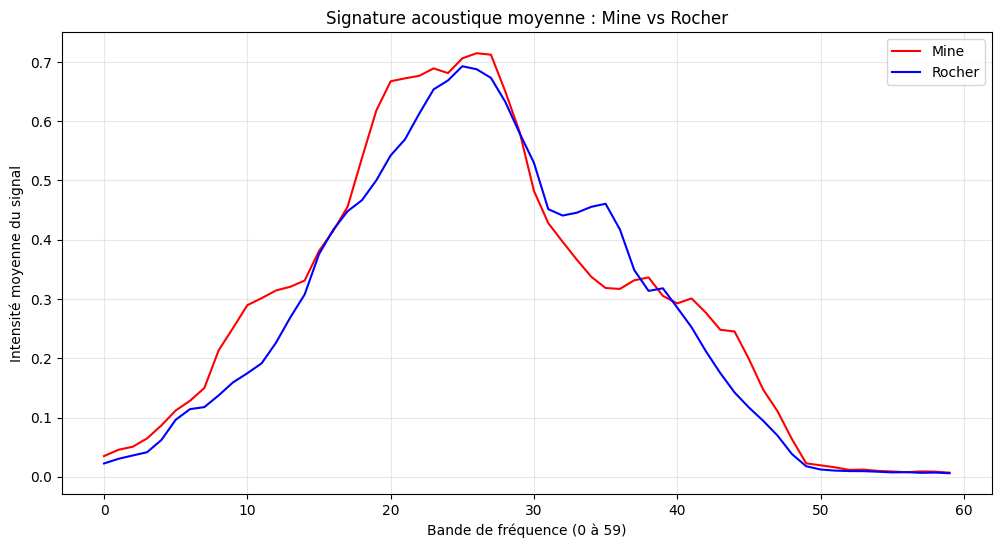

In [8]:
# Visualisation
plt.figure(figsize=(12, 6))

mean_mine = sonar[sonar[60] == 'M'].iloc[:, :60].mean()
mean_rock = sonar[sonar[60] == 'R'].iloc[:, :60].mean()

sns.lineplot(x=mean_mine.index, y=mean_mine.values, label='Mine', color='red')
sns.lineplot(x=mean_rock.index, y=mean_rock.values, label='Rocher', color='blue')

plt.title('Signature acoustique moyenne : Mine vs Rocher')
plt.xlabel('Bande de fréquence (0 à 59)')
plt.ylabel('Intensité moyenne du signal')
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# Preparation pour faire traiter les données
X = sonar.drop(60, axis=1)
y = sonar[60]

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# resultats
results = {}

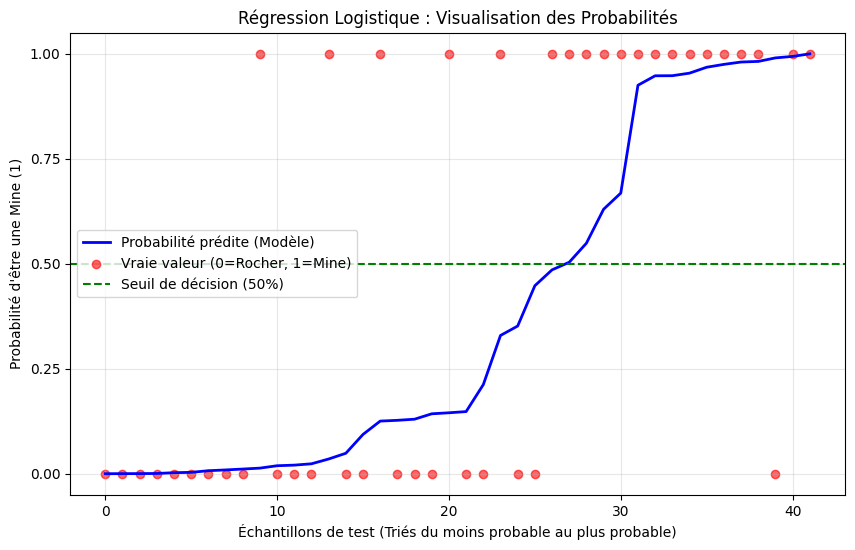

In [10]:
# Régression Logisitque
model_lr = LogisticRegression()
scores_lr = cross_val_score(model_lr, X_train, y_train, cv=5)

results['Reg. Logistique'] = np.mean(scores_lr)
model_lr.fit(X_train, y_train)

# ---------------------------------------
# Visualisation
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

sorted_indices = np.argsort(y_prob_lr)
y_prob_sorted = y_prob_lr[sorted_indices]
y_test_sorted = y_test[sorted_indices]

plt.figure(figsize=(10, 6))

plt.plot(y_prob_sorted, color='blue', linewidth=2, label='Probabilité prédite (Modèle)')
plt.scatter(range(len(y_test_sorted)), y_test_sorted, color='red', alpha=0.6, label='Vraie valeur (0=Rocher, 1=Mine)')
plt.axhline(y=0.5, color='green', linestyle='--', label='Seuil de décision (50%)')

plt.title("Régression Logistique : Visualisation des Probabilités")
plt.xlabel("Échantillons de test (Triés du moins probable au plus probable)")
plt.ylabel("Probabilité d'être une Mine (1)")
plt.yticks([0, 0.25, 0.5, 0.75, 1])
plt.legend(loc='center left')
plt.grid(True, alpha=0.3)
plt.show()

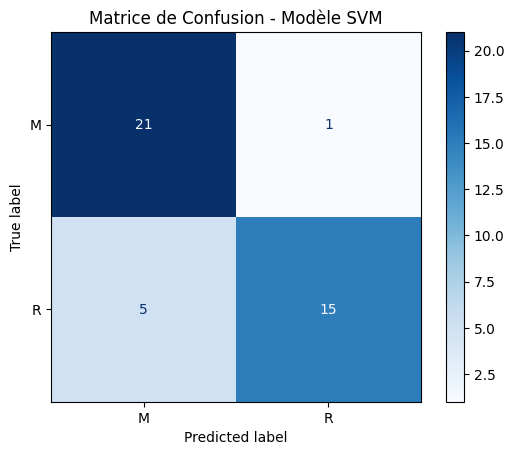

In [11]:
# Support Vector Machine
model_svm = SVC()
scores_svm = cross_val_score(model_svm, X_train, y_train, cv=5)

results['SVM'] = np.mean(scores_svm)
model_svm.fit(X_train, y_train)

# ---------------------------------------
# Visualisation

y_pred_svm = model_svm.predict(X_test)
cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', values_format='d')

plt.title('Matrice de Confusion - Modèle SVM')
plt.show()

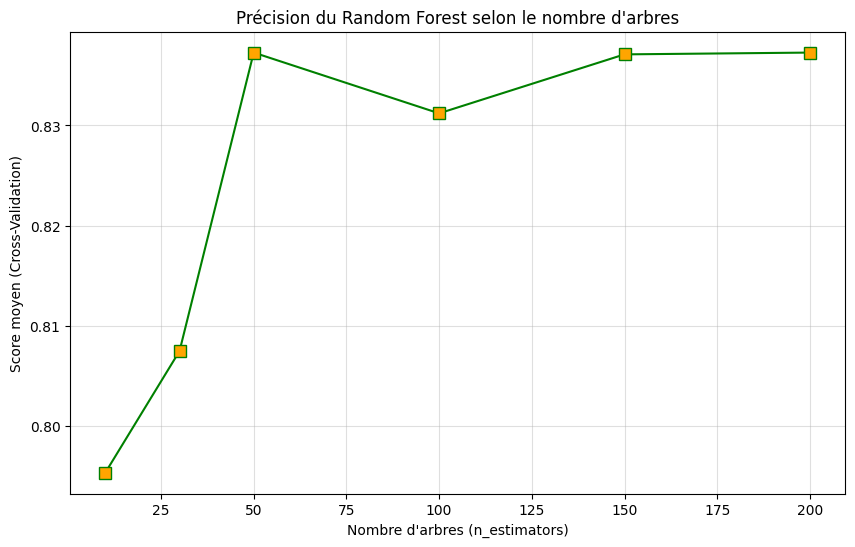

In [12]:
# Random forest
model_rf = RandomForestClassifier(n_estimators=150, random_state=42)
scores_rf = cross_val_score(model_rf, X_train, y_train, cv=5)

results['Random Forest'] = np.mean(scores_rf)
model_rf.fit(X_train, y_train)

# ---------------------------------------
# Visualisation

n_trees_list = [10, 30, 50, 100, 150, 200]
cv_scores_trees = []

for n in n_trees_list:
    rf_eval = RandomForestClassifier(n_estimators=n, random_state=42)
    scores = cross_val_score(rf_eval, X_train, y_train, cv=5)
    cv_scores_trees.append(np.mean(scores))

plt.figure(figsize=(10, 6))
plt.plot(n_trees_list, cv_scores_trees, marker='s', color='green', markerfacecolor='orange', markersize=8)

plt.title("Précision du Random Forest selon le nombre d'arbres")
plt.xlabel("Nombre d'arbres (n_estimators)")
plt.ylabel("Score moyen (Cross-Validation)")
plt.grid(True, alpha=0.4)
plt.show()

,Modèle,Score Validation Croisée Moyen
0,SVM,0.849376
1,Random Forest,0.837077
2,Reg. Logistique,0.765062


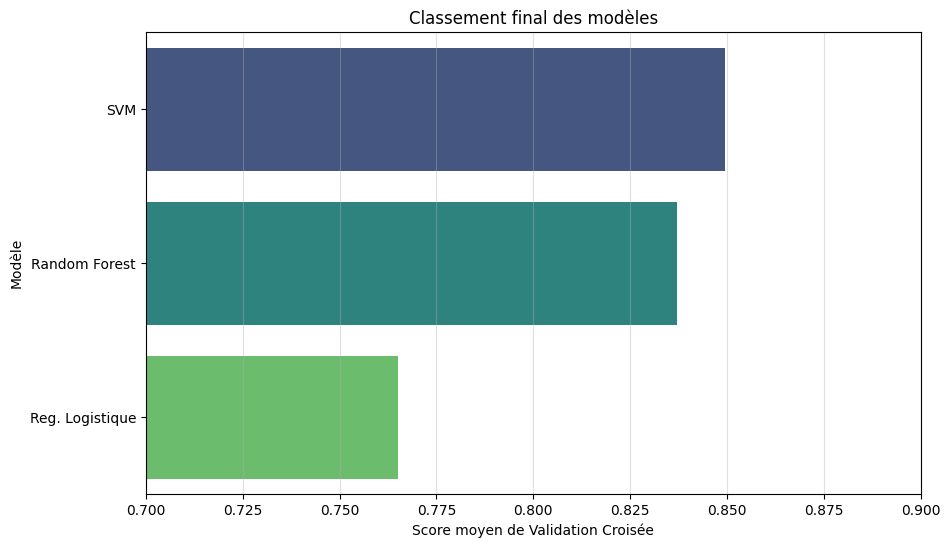

In [13]:
df_results = pd.DataFrame(list(results.items()), columns=['Modèle', 'Score Validation Croisée Moyen'])
df_results = df_results.sort_values(by='Score Validation Croisée Moyen', ascending=False).reset_index(drop=True)

display(df_results)

plt.figure(figsize=(10, 6))
sns.barplot(x='Score Validation Croisée Moyen', y='Modèle', data=df_results, hue='Modèle', palette='viridis', legend=False)
plt.title('Classement final des modèles')
plt.xlabel('Score moyen de Validation Croisée')
plt.ylabel('Modèle')
plt.xlim(0.7, 0.9)
plt.grid(axis='x', alpha=0.4)
plt.show()